In [1]:
# ============================================================================
#  FictiPay Churn — improved pipeline (survival/hazard features + safe ensemble)
#  Baseline this builds on: AUC 0.98531 (the WINNING config, not the V3 regress).
# ============================================================================
import os, gc, glob, json, warnings, math
import numpy as np
import polars as pl
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# ---- Feature/efficiency switches (flip if a Kaggle session is memory-tight) ---
USE_GPU         = True    # GPU training for LGBM / XGB
COMPUTE_MAXGAP  = True    # heavier max-gap / gap-std features (1 sort over distinct
                          #   active dates). Cheap mean_gap path is ALWAYS on, so
                          #   setting this False still keeps the core survival signal.
USE_CATBOOST    = False   # OFF by default: V3 showed a deep CatBoost hurt. Code path
                          #   is gated on OOF improvement so it can never silently hurt.
# ============ EXPERIMENT FLAGS (flip one at a time, measure OOF delta) ======
EXP1_DIVERGENCE  = True   # Exp1: txn-vs-balance/incoming recency divergence
                          #   (targets false-alarm cluster; residual-tree key axis)
EXP2_CADENCE_EMP = True   # Exp2: empirical cadence -- recency %-ile in gap CDF,
                          #   forward survival, recency x gap_cv interaction
                          #   (targets hardest cohort: non-unprecedented silence churners)
EXP3_INACTIVE_IX = True   # Exp3: inactive_days_30d x balance/incoming interactions
                          #   (separates truly-dormant from outgoing-only-quiet)
EXP4_SPW_ABLATION= False  # Exp4: compare SPW in {1.0, sqrt(SPW), SPW} on 3-fold OOF
                          #   OFF by default (adds ~10min); motivated by all-negative
                          #   residual-tree leaves (model over-predicts everywhere).
EXP5_DECORR_ENS  = True   # Exp5: seed-bagged LGBMs + lambdarank + rank-avg ensemble;
                          #   pairwise OOF correlation matrix printed to spot dead weight

RUN_OPTUNA      = False    # OFF by default: context.md shows features, not HPs, are the
                          #   bottleneck; tuning risks session timeout. Defaults are solid.

# ---- Paths: auto-detect the Kaggle input root --------------------------------
candidates = glob.glob('/kaggle/input/*')
DATA_ROOT = candidates[0] if candidates else './data'
print('DATA_ROOT =', DATA_ROOT)

TRX_FILES  = sorted(glob.glob(f'{DATA_ROOT}/**/trx_*.parquet', recursive=True))
BAL_FILES  = sorted(glob.glob(f'{DATA_ROOT}/**/balance_*.parquet', recursive=True))
KYC_FILE   = glob.glob(f'{DATA_ROOT}/**/kyc.parquet', recursive=True)[0]
TRAIN_FILE = glob.glob(f'{DATA_ROOT}/**/train_labels.csv', recursive=True)[0]
TEST_FILE  = glob.glob(f'{DATA_ROOT}/**/test.csv', recursive=True)[0]
print(f'{len(TRX_FILES)} transaction files | {len(BAL_FILES)} balance files')

os.makedirs('explainability', exist_ok=True)

# ---- Polars version-robust streaming collect ---------------------------------
# Newer Polars wants .collect(engine="streaming"); older accepts streaming=True.
def collect_stream(lf):
    try:
        return lf.collect(engine="streaming")
    except TypeError:
        return lf.collect(streaming=True)


DATA_ROOT = /kaggle/input/competitions
3 transaction files | 3 balance files


In [6]:
print("TRX FILES:");  [print("  ", f) for f in TRX_FILES]
print("\nBAL FILES:"); [print("  ", f) for f in BAL_FILES]
print("\nKYC:", KYC_FILE, "\nTRAIN:", TRAIN_FILE, "\nTEST:", TEST_FILE)

TRX FILES:
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-01.parquet
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-02.parquet
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/transactions/trx_2024-03.parquet

BAL FILES:
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-01.parquet
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-02.parquet
   /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/dayend_balance/balance_2024-03.parquet

KYC: /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/kyc.parquet 
TRAIN: /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/train_labels.csv 
TEST: /kaggle/input/competitions/bkash-presents-nsucec-datathon/public/test.csv


In [7]:
# ---- [1] Small tables --------------------------------------------------------
from datetime import datetime, timedelta

kyc          = pl.read_parquet(KYC_FILE)
train_labels = pl.read_csv(TRAIN_FILE)
test_ids     = pl.read_csv(TEST_FILE)

kyc_cust = kyc.filter(pl.col('ACCOUNT_TYPE') == 'Customer')

needed_ids = pl.concat([
    train_labels.select('ACCOUNT_ID'),
    test_ids.select('ACCOUNT_ID'),
]).unique()

kyc_cust     = kyc_cust.join(needed_ids, on='ACCOUNT_ID', how='inner')
CUSTOMER_IDS = kyc_cust.select('ACCOUNT_ID')          # small frame for semi-joins

print(f'KYC rows (all): {kyc.height:,} | Customer & needed: {kyc_cust.height:,}')
print(f'train: {train_labels.height:,} | test: {test_ids.height:,}')
del kyc; gc.collect()

# ---- Recency anchor: the prediction-window boundary --------------------------
# The label is "no transaction in 2024-04 -> April 1 is the instant we measure
# silence to. (Pinning to the boundary, not the last observed datetime, keeps
# every recency feature consistent for customers whose last activity differs.)
ANCHOR      = datetime(2024, 4, 1)
ANCHOR_DATE = pl.lit(ANCHOR)
print('Recency anchor pinned to window boundary:', ANCHOR)

KYC rows (all): 1,000,000 | Customer & needed: 850,000
train: 595,000 | test: 255,000
Recency anchor pinned to window boundary: 2024-04-01 00:00:00


# Feature engineering

In [8]:
# ---- [2a] Transaction features: per-file conditional aggregation -------------
# Same sufficient-statistic pattern as the baseline (200M rows never materialise),
# PLUS three new cheap per-account stats that let us reconstruct the customer's
# transaction *cadence* later: min active date, max active date, distinct active
# days. From those alone we get mean_gap = span/(ndays-1) with NO global sort.

WINDOW_START = datetime(2024, 4, 1)
W3  = ANCHOR - timedelta(days=3);   W5  = ANCHOR - timedelta(days=5)
W7  = ANCHOR - timedelta(days=7);   W10 = ANCHOR - timedelta(days=10)
W14 = ANCHOR - timedelta(days=14);  W30 = ANCHOR - timedelta(days=30)
W90 = ANCHOR - timedelta(days=90)
def in_w(col, lo): return pl.col(col) >= pl.lit(lo)

trx_parts, dst_parts, day_parts, srcdate_parts = [], [], [], []
for f in TRX_FILES:
    lf = (
        pl.scan_parquet(f)
          .with_columns(pl.col('TRX_DATETIME').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False))
          .filter(in_w('TRX_DATETIME', W90))
          .rename({'SRC_ACCOUNT': 'ACCOUNT_ID'})
          .join(CUSTOMER_IDS.lazy(), on='ACCOUNT_ID', how='inner')
          .select('ACCOUNT_ID', 'TRX_DATETIME', 'DST_ACCOUNT', 'TRX_TYPE', 'TRX_AMT')
          .with_columns(pl.col('TRX_DATETIME').dt.date().alias('d'))
    )
    agg = lf.group_by('ACCOUNT_ID').agg([
        in_w('TRX_DATETIME', W7 ).sum().alias('cnt_7'),
        in_w('TRX_DATETIME', W30).sum().alias('cnt_30'),
        pl.len().alias('cnt_90'),
        in_w('TRX_DATETIME', W3 ).sum().alias('cnt_3'),
        in_w('TRX_DATETIME', W5 ).sum().alias('cnt_5'),
        in_w('TRX_DATETIME', W10).sum().alias('cnt_10'),
        in_w('TRX_DATETIME', W14).sum().alias('cnt_14'),
        (pl.col('TRX_DATETIME').dt.month() == 1).sum().alias('cnt_jan'),
        (pl.col('TRX_DATETIME').dt.month() == 2).sum().alias('cnt_feb'),
        (pl.col('TRX_DATETIME').dt.month() == 3).sum().alias('cnt_mar'),
        pl.when(in_w('TRX_DATETIME', W30)).then(pl.col('TRX_AMT')).otherwise(0.0).sum().alias('amt_sum_30'),
        pl.when(in_w('TRX_DATETIME', W30)).then(pl.col('TRX_AMT')**2).otherwise(0.0).sum().alias('amt_ssq_30'),
        (in_w('TRX_DATETIME', W30) & (pl.col('TRX_TYPE')=='P2P')).sum().alias('p2p_30'),
        (in_w('TRX_DATETIME', W30) & (pl.col('TRX_TYPE')=='MerchantPay')).sum().alias('mer_30'),
        (in_w('TRX_DATETIME', W30) & (pl.col('TRX_TYPE')=='BillPay')).sum().alias('bil_30'),
        (in_w('TRX_DATETIME', W30) & (pl.col('TRX_TYPE')=='CashIn')).sum().alias('cin_30'),
        (in_w('TRX_DATETIME', W30) & (pl.col('TRX_TYPE')=='CashOut')).sum().alias('cout_30'),
        pl.col('TRX_DATETIME').max().alias('last_trx'),
        # ---- NEW cadence sufficient stats (90d window) ----
        pl.col('d').min().alias('min_d_90'),
        pl.col('d').max().alias('max_d_90'),
        pl.col('d').n_unique().alias('ndays_90'),
    ]).pipe(collect_stream)
    trx_parts.append(agg)

    dst_parts.append(collect_stream(
        lf.filter(in_w('TRX_DATETIME', W30)).select('ACCOUNT_ID','DST_ACCOUNT').unique()))
    day_parts.append(collect_stream(
        lf.filter(in_w('TRX_DATETIME', W30)).select('ACCOUNT_ID', pl.col('d')).unique()))
    if COMPUTE_MAXGAP:    # keep distinct 90d active dates for the max-gap sort
        srcdate_parts.append(collect_stream(lf.select('ACCOUNT_ID','d').unique()))
    gc.collect()

# Combine sufficient stats across files (min-of-mins, max-of-maxes, sum-of-counts)
trx_stats = pl.concat(trx_parts).group_by('ACCOUNT_ID').agg([
    pl.sum('cnt_7'), pl.sum('cnt_30'), pl.sum('cnt_90'),
    pl.sum('cnt_3'), pl.sum('cnt_5'), pl.sum('cnt_10'), pl.sum('cnt_14'),
    pl.sum('cnt_jan'), pl.sum('cnt_feb'), pl.sum('cnt_mar'),
    pl.sum('amt_sum_30'), pl.sum('amt_ssq_30'),
    pl.sum('p2p_30'), pl.sum('mer_30'), pl.sum('bil_30'),
    pl.sum('cin_30'), pl.sum('cout_30'),
    pl.max('last_trx'),
    pl.min('min_d_90').alias('min_d_90'),
    pl.max('max_d_90').alias('max_d_90'),
    pl.sum('ndays_90').alias('ndays_90'),   # distinct days per month are disjoint -> summing is exact
])
uniq_dst    = (pl.concat(dst_parts).unique()
                 .group_by('ACCOUNT_ID').agg(pl.len().alias('unique_dst_accounts_30d')))
active_days = (pl.concat(day_parts).unique()
                 .group_by('ACCOUNT_ID').agg(pl.len().alias('active_days_30')))
del trx_parts, dst_parts, day_parts; gc.collect()
print('trx_stats:', trx_stats.shape)

trx_stats: (847929, 22)


In [9]:
# ---- [2a-gap] OPTIONAL: max gap & gap volatility from distinct active dates ---
# mean_gap (computed cheaply in [2b]) captures average cadence. max_gap answers a
# different, powerful question for an inactivity label: "has this customer EVER
# stayed silent this long before?" If days_since_last_txn > their historical
# max_gap, the customer is in *unprecedented* silence -> strong churn signal.
# One sort over distinct (account, date) rows only (daily resolution keeps it small).
if COMPUTE_MAXGAP and srcdate_parts:
    src_dates = pl.concat(srcdate_parts).unique()
    gap_stats = (
        src_dates.sort(['ACCOUNT_ID','d'])
                 .with_columns(pl.col('d').cast(pl.Int32).diff().over('ACCOUNT_ID').alias('gap'))
                 .filter(pl.col('gap').is_not_null())
                 .group_by('ACCOUNT_ID').agg([
                     pl.col('gap').max().alias('gap_max'),
                     pl.col('gap').std().alias('gap_std'),
                     pl.col('gap').median().alias('gap_median'),
                 ])
    )
    del src_dates, srcdate_parts; gc.collect()
    print('gap_stats:', gap_stats.shape)
else:
    gap_stats = pl.DataFrame({'ACCOUNT_ID': [], 'gap_max': [], 'gap_std': [], 'gap_median': []})
    print('max-gap features skipped (COMPUTE_MAXGAP=False)')

gap_stats: (842027, 4)


In [10]:
# ---- [2b] Derive transaction features (baseline set + survival/hazard) --------
EPS = 1e-9
n30 = pl.col('cnt_30').cast(pl.Float64)

trx_feat = (
    trx_stats
    .join(uniq_dst,    on='ACCOUNT_ID', how='left')
    .join(active_days, on='ACCOUNT_ID', how='left')
    .join(gap_stats,   on='ACCOUNT_ID', how='left')
    .with_columns([
        # ---- baseline features (unchanged) ----
        pl.col('cnt_7').alias('txn_count_7d'),
        pl.col('cnt_30').alias('txn_count_30d'),
        pl.col('cnt_90').alias('txn_count_90d'),
        (pl.col('amt_sum_30') / (n30 + EPS)).alias('txn_amt_mean_30d'),
        pl.when(pl.col('cnt_30') > 1)
          .then(((pl.col('amt_ssq_30') - pl.col('amt_sum_30')**2 / (n30+EPS)) / (n30 - 1))
                .clip(lower_bound=0).sqrt())
          .otherwise(0.0).alias('txn_amt_std_30d'),
        pl.col('amt_sum_30').alias('txn_amt_sum_30d'),
        ((ANCHOR_DATE - pl.col('last_trx')).dt.total_hours() / 24.0).alias('days_since_last_txn'),
        (pl.col('p2p_30')  / (n30 + EPS)).alias('p2p_ratio_30d'),
        (pl.col('mer_30')  / (n30 + EPS)).alias('merchant_ratio_30d'),
        (pl.col('bil_30')  / (n30 + EPS)).alias('bill_ratio_30d'),
        (pl.col('cout_30') / (n30 + EPS)).alias('cashout_ratio_30d'),
        (pl.col('cin_30')  / (n30 + EPS)).alias('cashin_ratio_30d'),
        pl.col('unique_dst_accounts_30d').fill_null(0),
        ((n30 - pl.col('cnt_7').cast(pl.Float64) * 4.3) / (n30 + EPS)).alias('txn_count_trend'),
        (30 - pl.col('active_days_30').fill_null(0)).clip(lower_bound=0).alias('inactive_days_30d'),
        pl.col('cnt_3').alias('txn_count_last_3d'),
        pl.col('cnt_5').alias('txn_count_last_5d'),
        pl.col('cnt_10').alias('txn_count_last_10d'),
        pl.col('cnt_14').alias('txn_count_last_14d'),
        (pl.col('cnt_3')  > 0).cast(pl.Int8).alias('active_last_3d'),
        (pl.col('cnt_5')  > 0).cast(pl.Int8).alias('active_last_5d'),
        (pl.col('cnt_10') > 0).cast(pl.Int8).alias('active_last_10d'),
        pl.col('cnt_jan').alias('txn_count_jan'),
        pl.col('cnt_feb').alias('txn_count_feb'),
        pl.col('cnt_mar').alias('txn_count_mar'),
        ((pl.col('cnt_mar') - pl.col('cnt_jan')) / 2.0).alias('txn_count_monthly_slope'),
        (pl.col('cnt_mar').cast(pl.Float64)
            / (pl.col('cnt_jan') + pl.col('cnt_feb') + pl.col('cnt_mar') + 1.0))
            .alias('march_activity_share'),

        # =================== NEW: CADENCE / SURVIVAL / HAZARD ===================
        # active span in days and mean inter-active-day gap (cheap, no sort):
        (pl.col('max_d_90').cast(pl.Int32) - pl.col('min_d_90').cast(pl.Int32))
            .cast(pl.Float64).alias('active_span_days'),
    ])
    .with_columns([
        # mean_gap = span / (distinct_active_days - 1); a customer's typical rhythm
        (pl.col('active_span_days') / (pl.col('ndays_90') - 1).clip(lower_bound=1))
            .alias('gap_mean'),
        # coverage = fraction of days in their active span that had activity (regularity)
        (pl.col('ndays_90').cast(pl.Float64) / (pl.col('active_span_days') + 1.0))
            .alias('activity_coverage'),
        # analytic Poisson churn estimate: P(no event in 30d) = exp(-rate*30).
        # rate = events/day = cnt_90/90  ->  exp(-cnt_90/3). Bounded [0,1], aligned to label.
        (-(pl.col('cnt_90').cast(pl.Float64) / 90.0) * 30.0).exp().alias('churn_prob_poisson_out'),
    ])
    .with_columns([
        # THE hazard feature: silence measured in units of the customer's OWN cadence.
        # ~1 = on schedule (low risk); >>1 = badly overdue (high risk).
        (pl.col('days_since_last_txn') / (pl.col('gap_mean') + EPS)).alias('recency_over_gap_mean'),
        # unprecedented silence: longer gap than they have ever taken before
        (pl.col('days_since_last_txn') - pl.col('gap_max').cast(pl.Float64).fill_null(0.0))
            .alias('recency_minus_gap_max'),
        ((pl.col('days_since_last_txn') > pl.col('gap_max').cast(pl.Float64).fill_null(0.0))
            .cast(pl.Int8)).alias('unprecedented_silence'),
        # gap volatility (bursty vs metronomic users behave differently near the boundary)
        (pl.col('gap_std').cast(pl.Float64) / (pl.col('gap_mean') + EPS)).alias('gap_cv'),
        pl.col('gap_max').cast(pl.Float64).alias('gap_max'),
        pl.col('gap_median').cast(pl.Float64).alias('gap_median'),
    ])
    .select(['ACCOUNT_ID',
             'txn_count_7d','txn_count_30d','txn_count_90d',
             'txn_amt_mean_30d','txn_amt_std_30d','txn_amt_sum_30d',
             'days_since_last_txn','p2p_ratio_30d','merchant_ratio_30d',
             'bill_ratio_30d','cashout_ratio_30d','cashin_ratio_30d',
             'unique_dst_accounts_30d','txn_count_trend','inactive_days_30d',
             'txn_count_last_3d','txn_count_last_5d','txn_count_last_10d','txn_count_last_14d',
             'active_last_3d','active_last_5d','active_last_10d',
             'txn_count_jan','txn_count_feb','txn_count_mar',
             'txn_count_monthly_slope','march_activity_share',
             # new survival/cadence block:
             'active_span_days','gap_mean','activity_coverage','churn_prob_poisson_out',
             'recency_over_gap_mean','recency_minus_gap_max','unprecedented_silence',
             'gap_cv','gap_max','gap_median'])
)
del trx_stats, uniq_dst, active_days, gap_stats; gc.collect()
print('trx_feat:', trx_feat.shape)
trx_feat.head(3)

trx_feat: (847929, 38)


ACCOUNT_ID,txn_count_7d,txn_count_30d,txn_count_90d,txn_amt_mean_30d,txn_amt_std_30d,txn_amt_sum_30d,days_since_last_txn,p2p_ratio_30d,merchant_ratio_30d,bill_ratio_30d,cashout_ratio_30d,cashin_ratio_30d,unique_dst_accounts_30d,txn_count_trend,inactive_days_30d,txn_count_last_3d,txn_count_last_5d,txn_count_last_10d,txn_count_last_14d,active_last_3d,active_last_5d,active_last_10d,txn_count_jan,txn_count_feb,txn_count_mar,txn_count_monthly_slope,march_activity_share,active_span_days,gap_mean,activity_coverage,churn_prob_poisson_out,recency_over_gap_mean,recency_minus_gap_max,unprecedented_silence,gap_cv,gap_max,gap_median
str,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,u32,u32,u32,u32,u32,i8,i8,i8,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,i8,f64,f64,f64
"""CUST00280638""",9,48,134,3531.452292,6029.385639,169509.71,0.291667,0.6875,0.020833,0.0625,0.0,0.229167,38,0.19375,5,6,7,15,22,1,1,1,47,36,51,2.0,0.377778,89.0,1.219178,0.822222,3.9950e-20,0.239232,-2.708333,0,0.392571,3.0,1.0
"""CUST00613799""",14,53,141,7102.549245,15608.251463,376435.11,0.166667,0.169811,0.584906,0.226415,0.018868,0.0,53,-0.135849,9,3,13,21,30,1,1,1,46,42,53,3.5,0.373239,89.0,1.369231,0.733333,3.8740e-21,0.121723,-3.833333,0,0.457723,4.0,1.0
"""CUST00822796""",4,7,36,4331.732857,10616.426772,30322.13,0.333333,0.142857,0.0,0.857143,0.0,0.0,7,-1.457143,25,3,3,4,7,1,1,1,17,11,8,2.1475e9,0.216216,89.0,3.423077,0.3,0.000006,0.097378,-17.666667,0,1.015934,18.0,2.0


In [11]:
# ---- [2c] Balance features: same sufficient-statistic pattern ----------------
# NOTE: V3 dropped zero_balance_days_30d / min_balance_30d / avg_balance_90d and
# the score FELL. They are high-SHAP signals, so we keep the full set here.
ZERO_THRESH = 1.0

bal_parts = []
for f in BAL_FILES:
    lf = (
        pl.scan_parquet(f)
          .with_columns(pl.col('DATE').str.to_date(format='%Y-%m-%d', strict=False))
          .filter(in_w('DATE', W90.date()))
          .join(CUSTOMER_IDS.lazy(), on='ACCOUNT_ID', how='inner')
    )
    agg = lf.group_by('ACCOUNT_ID').agg([
        pl.when(in_w('DATE', W30.date())).then(pl.col('AVAILABLE_BALANCE')).otherwise(None).sum().alias('b_sum_30'),
        pl.when(in_w('DATE', W30.date())).then(pl.col('AVAILABLE_BALANCE')**2).otherwise(None).sum().alias('b_ssq_30'),
        in_w('DATE', W30.date()).sum().alias('b_n_30'),
        pl.when(in_w('DATE', W30.date())).then(pl.col('AVAILABLE_BALANCE')).otherwise(None).min().alias('b_min_30'),
        (in_w('DATE', W30.date()) & (pl.col('AVAILABLE_BALANCE') < ZERO_THRESH)).sum().alias('b_zero_30'),
        pl.col('AVAILABLE_BALANCE').sum().alias('b_sum_90'),
        pl.len().alias('b_n_90'),
        pl.when(in_w('DATE', W7.date())).then(pl.col('AVAILABLE_BALANCE')).otherwise(None).sum().alias('b_sum_l7'),
        in_w('DATE', W7.date()).sum().alias('b_n_l7'),
        pl.when(in_w('DATE', W14.date()) & ~in_w('DATE', W7.date()))
          .then(pl.col('AVAILABLE_BALANCE')).otherwise(None).sum().alias('b_sum_p7'),
        (in_w('DATE', W14.date()) & ~in_w('DATE', W7.date())).sum().alias('b_n_p7'),
    ]).pipe(collect_stream)
    bal_parts.append(agg); gc.collect()

bal_stats = pl.concat(bal_parts).group_by('ACCOUNT_ID').agg([
    pl.sum('b_sum_30'), pl.sum('b_ssq_30'), pl.sum('b_n_30'),
    pl.min('b_min_30'), pl.sum('b_zero_30'),
    pl.sum('b_sum_90'), pl.sum('b_n_90'),
    pl.sum('b_sum_l7'), pl.sum('b_n_l7'), pl.sum('b_sum_p7'), pl.sum('b_n_p7'),
])
del bal_parts; gc.collect()

n30b   = pl.col('b_n_30').cast(pl.Float64)
avg_l7 = pl.col('b_sum_l7') / (pl.col('b_n_l7').cast(pl.Float64) + EPS)
avg_p7 = pl.col('b_sum_p7') / (pl.col('b_n_p7').cast(pl.Float64) + EPS)

bal_feat = bal_stats.with_columns([
    (pl.col('b_sum_30') / (n30b + EPS)).alias('avg_balance_30d'),
    (pl.col('b_sum_90') / (pl.col('b_n_90').cast(pl.Float64) + EPS)).alias('avg_balance_90d'),
    pl.when(pl.col('b_n_30') > 1)
      .then(((pl.col('b_ssq_30') - pl.col('b_sum_30')**2/(n30b+EPS)) / (n30b-1))
            .clip(lower_bound=0).sqrt())
      .otherwise(0.0).alias('balance_std_30d'),
    pl.col('b_min_30').alias('min_balance_30d'),
    ((avg_l7 - avg_p7) / (avg_p7 + 1.0)).alias('balance_trend'),
    pl.col('b_zero_30').alias('zero_balance_days_30d'),
]).select(['ACCOUNT_ID','avg_balance_30d','avg_balance_90d','balance_std_30d',
           'min_balance_30d','balance_trend','zero_balance_days_30d'])
del bal_stats; gc.collect()
print('bal_feat:', bal_feat.shape)

bal_feat: (850000, 7)


In [12]:
# ---- [2-INCOMING] Receiving-side activity: customer as DST_ACCOUNT -----------
# Baseline features only see money SENT (SRC). The label counts ANY transaction,
# so a customer who only RECEIVES looks silent to the sender pipeline but is
# active for the label. We add incoming counts, incoming recency, AND the incoming
# analogue of the cadence stats so "any-activity" survival can be built later.
in_parts = []
for f in TRX_FILES:
    lf = (
        pl.scan_parquet(f)
          .with_columns(pl.col('TRX_DATETIME').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False))
          .filter(in_w('TRX_DATETIME', W90))
          .rename({'DST_ACCOUNT': 'ACCOUNT_ID'})              # customer is the RECEIVER
          .join(CUSTOMER_IDS.lazy(), on='ACCOUNT_ID', how='inner')
          .select('ACCOUNT_ID', 'TRX_DATETIME')
    )
    agg = lf.group_by('ACCOUNT_ID').agg([
        in_w('TRX_DATETIME', W3 ).sum().alias('in_cnt_3'),
        in_w('TRX_DATETIME', W7 ).sum().alias('in_cnt_7'),
        in_w('TRX_DATETIME', W30).sum().alias('in_cnt_30'),
        pl.len().alias('in_cnt_90'),
        pl.col('TRX_DATETIME').max().alias('last_in_trx'),
    ]).pipe(collect_stream)
    in_parts.append(agg); gc.collect()

in_stats = pl.concat(in_parts).group_by('ACCOUNT_ID').agg([
    pl.sum('in_cnt_3'), pl.sum('in_cnt_7'), pl.sum('in_cnt_30'),
    pl.sum('in_cnt_90'), pl.max('last_in_trx'),
])
in_feat = in_stats.with_columns([
    pl.col('in_cnt_7').alias('incoming_count_7d'),
    pl.col('in_cnt_30').alias('incoming_count_30d'),
    pl.col('in_cnt_90').alias('incoming_count_90d'),
    (pl.col('in_cnt_3') > 0).cast(pl.Int8).alias('incoming_active_last_3d'),
    ((ANCHOR_DATE - pl.col('last_in_trx')).dt.total_hours() / 24.0).alias('days_since_last_incoming'),
]).select(['ACCOUNT_ID','incoming_count_7d','incoming_count_30d','incoming_count_90d',
           'incoming_active_last_3d','days_since_last_incoming'])
del in_parts, in_stats; gc.collect()

print('in_feat:', in_feat.shape)

in_feat: (664681, 6)


In [13]:
# ---- [2c-extra] Balance-change activity: a DAILY any-activity proxy ----------
# DayEndBalance is a complete daily panel: if the end-of-day balance moves, the
# account transacted that day (as sender OR receiver). So balance-change recency
# is a clean "days since last activity of ANY kind" that does not depend on which
# column the customer sat in. Cheap: per-file within-account diff + counts only
# (no global sort). The Jan/Feb/Mar boundary day is slightly under-counted -- an
# acceptable approximation that costs no memory.
balc_parts = []
for f in BAL_FILES:
    lf = (
        pl.scan_parquet(f)
          .with_columns(pl.col('DATE').str.to_date(format='%Y-%m-%d', strict=False))
          .filter(in_w('DATE', W90.date()))
          .join(CUSTOMER_IDS.lazy(), on='ACCOUNT_ID', how='inner')
          .select('ACCOUNT_ID', 'DATE', 'AVAILABLE_BALANCE')
          .sort('ACCOUNT_ID', 'DATE')
          .with_columns((pl.col('AVAILABLE_BALANCE').diff().over('ACCOUNT_ID').abs() > 1e-6).alias('chg'))
    )
    agg = (lf.filter(pl.col('chg'))
             .group_by('ACCOUNT_ID')
             .agg([pl.col('DATE').max().alias('last_chg'),
                   pl.len().alias('n_chg')])
             .pipe(collect_stream))
    balc_parts.append(agg); gc.collect()

bal_change = (pl.concat(balc_parts)
                .group_by('ACCOUNT_ID')
                .agg([pl.max('last_chg').alias('last_chg'), pl.sum('n_chg').alias('n_chg')])
                .with_columns([
                    (pl.lit(ANCHOR.date()) - pl.col('last_chg')).dt.total_days()
                        .cast(pl.Float64).alias('days_since_balance_change'),
                    pl.col('n_chg').alias('balance_change_count_90d'),
                    (90.0 / (pl.col('n_chg').cast(pl.Float64) + 1.0)).alias('balance_change_gap_mean'),
                ])
                .select('ACCOUNT_ID','days_since_balance_change',
                        'balance_change_count_90d','balance_change_gap_mean'))
del balc_parts; gc.collect()
print('bal_change:', bal_change.shape)

bal_change: (843547, 4)


In [14]:
# ---- [2d] KYC + assemble full matrix + cross-source survival composites ------
kyc_feat = kyc_cust.select([
    'ACCOUNT_ID',
    (pl.lit(ANCHOR.date()) - pl.col('ACCOUNT_OPEN_DATE').cast(pl.Date))
        .dt.total_days().alias('account_age_days'),
    pl.col('GENDER').cast(pl.Categorical).to_physical().alias('gender_encoded'),
    pl.col('REGION'),
])

features = (
    needed_ids
    .join(kyc_feat,   on='ACCOUNT_ID', how='left')
    .join(trx_feat,   on='ACCOUNT_ID', how='left')
    .join(bal_feat,   on='ACCOUNT_ID', how='left')
    .join(in_feat,    on='ACCOUNT_ID', how='left')
    .join(bal_change, on='ACCOUNT_ID', how='left')
)

# ---- baseline-style derived features ----
features = features.with_columns([
    (pl.col('txn_amt_sum_30d') / (pl.col('avg_balance_30d') + 1.0)).alias('spend_to_balance_ratio'),
    pl.col('incoming_count_7d').fill_null(0),
    pl.col('incoming_count_30d').fill_null(0),
    pl.col('incoming_count_90d').fill_null(0),
    pl.col('incoming_active_last_3d').fill_null(0),
    pl.col('days_since_last_incoming').fill_null(120.0),
    pl.col('days_since_balance_change').fill_null(120.0),
    pl.col('balance_change_count_90d').fill_null(0),
    pl.col('balance_change_gap_mean').fill_null(90.0),
])

# ---- engagement score (baseline composite) ----
def norm(c):
    return (pl.col(c) - pl.col(c).min()) / (pl.col(c).max() - pl.col(c).min() + EPS)
features = features.with_columns(
    (0.4*norm('txn_count_30d') + 0.3*(1 - norm('days_since_last_txn'))
     + 0.3*norm('unique_dst_accounts_30d')).alias('engagement_score'))

# =================== NEW cross-source survival composites ====================
# Multi-source "days since last activity of ANY kind": sent vs received vs
# balance-move -> the renewal process the inactivity label genuinely tests.
features = features.with_columns([
    pl.min_horizontal('days_since_last_txn',
                      'days_since_last_incoming',
                      'days_since_balance_change').alias('days_since_last_any_activity'),
    ((pl.col('active_last_3d').fill_null(0) > 0) |
     (pl.col('incoming_active_last_3d') > 0)).cast(pl.Int8).alias('any_active_last_3d'),
    (pl.col('txn_count_30d').fill_null(0) + pl.col('incoming_count_30d')).alias('total_activity_30d'),
    (pl.col('txn_count_90d').fill_null(0) + pl.col('incoming_count_90d')).alias('total_activity_90d'),
])
features = features.with_columns([
    # analytic Poisson churn estimate on ANY activity (sent + received)
    (-(pl.col('total_activity_90d').cast(pl.Float64) / 90.0) * 30.0).exp()
        .alias('churn_prob_poisson_any'),
    # hazard ratio on the unified recency, using outgoing cadence as the yardstick
    (pl.col('days_since_last_any_activity') / (pl.col('gap_mean') + EPS))
        .alias('any_recency_over_gap_mean'),
])


# =================== EXP1: TXN-vs-OTHER-ACTIVITY RECENCY DIVERGENCE ==========
# Rationale (misclassification EDA sect): the confident-error tree fires on the
# leaf [days_since_last_txn>22 AND days_since_balance_change<=4.5 -> class 1].
# These customers look churn-silent on outgoing txns but their BALANCE still moved
# recently -> they are alive.  Divergence features encode that axis directly.
# False-alarm cluster: unprecedented_silence=1 / high inactive_days but returned.
if EXP1_DIVERGENCE:
    features = features.with_columns([
        # (a) raw gap: positive = outgoing-silent but balance still moved recently
        (pl.col('days_since_last_txn') - pl.col('days_since_balance_change'))
            .alias('txn_vs_balance_recency_diff'),
        # (b) ratio: > 1 when outgoing-stale relative to balance activity; cap 10
        (pl.col('days_since_last_txn') / (pl.col('days_since_balance_change') + 1.0))
            .clip(upper_bound=10.0).alias('txn_vs_balance_recency_ratio'),
        # (c) gap vs incoming: positive = sent nothing recently but received activity
        (pl.col('days_since_last_txn') - pl.col('days_since_last_incoming'))
            .alias('txn_vs_incoming_recency_diff'),
        # (d) "alive but outgoing-quiet": no outgoing in 5d yet balance or incoming
        #     moved in 5d.  Strong NOT-churn signal for the false-alarm cluster.
        ((pl.col('active_last_5d') == 0) &
         ((pl.col('days_since_balance_change') <= 5.0) |
          (pl.col('incoming_active_last_3d') == 1))).cast(pl.Int8)
            .alias('alive_no_outgoing'),
    ])

# =================== EXP2: EMPIRICAL CADENCE-CONDITIONED RECENCY ==============
# Rationale: hardest cohort = churners whose silence was NOT unprecedented
# (n~19.8k, err=0.119, mean OOF 0.702).  They look like routine irregular absences.
# Parametric Poisson assumes constant rate; underperforms for high-gap_cv customers.
# We add three empirical quantities derived from existing cadence stats (no new sort):
#   (a) Recency percentile in the customer's own gap CDF: P(gap <= recency | history)
#       approx via Winitzki rational erf (pure Polars, fuses with lazy plan, < 0.05% error)
#   (b) Forward survival P(no event in 30d | already waited delta) -- directly encodes
#       how "overdue" the customer is relative to their OWN rhythm, not the population.
#   (c) days_since_last_txn * gap_cv interaction: high when BOTH overdue AND irregular.
if EXP2_CADENCE_EMP:
    import math as _math
    _SQRT2 = float(_math.sqrt(2.0))
    _A = 0.147  # Winitzki (2008) constant; max absolute erf error < 0.0005

    def _polars_erf_approx(e):
        """Approximate erf(x) in Polars using Winitzki rational formula."""
        x2 = e ** 2
        inner = (4.0 / _math.pi + _A * x2) / (1.0 + _A * x2)
        sign  = pl.when(e >= 0).then(1.0).otherwise(-1.0)
        return (1.0 - (-(x2 * inner)).exp()).sqrt() * sign

    def _phi(e):
        """Standard normal CDF: Phi(x) = 0.5*(1+erf(x/sqrt(2)))."""
        return 0.5 * (1.0 + _polars_erf_approx(e / _SQRT2))

    # gap_std ≈ gap_cv * gap_mean (gap_std not stored; gap_cv = gap_std/gap_mean)
    features = features.with_columns([
        ((pl.col('days_since_last_txn') - pl.col('gap_mean'))
         / (pl.col('gap_cv') * pl.col('gap_mean') + 1.0)).alias('_z'),
        ((pl.col('days_since_last_txn') + 30.0 - pl.col('gap_mean'))
         / (pl.col('gap_cv') * pl.col('gap_mean') + 1.0)).alias('_z30'),
    ])
    features = features.with_columns([
        # (a) recency percentile in gap CDF [0,1]; 1 = more overdue than any prior gap
        _phi(pl.col('_z')).clip(0.0, 1.0).alias('recency_pctile_in_gap_cdf'),
        # (b) forward survival: P(no event in next 30d | already waited recency days)
        (1.0 - _phi(pl.col('_z30')).clip(0.0, 1.0) /
         (1.0 - _phi(pl.col('_z')).clip(0.0, 0.9999) + 1e-9).clip(lower_bound=1e-9))
            .clip(0.0, 1.0).alias('empirical_forward_survival'),
        # (c) interaction: overdue × bursty; high for irregular long-absent customers
        (pl.col('days_since_last_txn') * pl.col('gap_cv')).alias('recency_x_gap_cv'),
    ]).drop(['_z', '_z30'])

# =================== EXP3: INACTIVE_DAYS_30D INTERACTIONS ====================
# Rationale: inactive_days_30d > 29 has a 0.891 churn-rate gap (best single split).
# But the residual tree shows the model massively over-predicts (leaf -0.33 / -0.42)
# when inactive_days_30d is high YET days_since_balance_change is LOW.  Products
# encode the joint condition the tree can only express with a two-level split.
if EXP3_INACTIVE_IX:
    features = features.with_columns([
        # (a) dormancy product: genuinely inactive AND balance also stale (both high)
        (pl.col('inactive_days_30d') * pl.col('days_since_balance_change') / 30.0)
            .alias('inactive_x_bal_change'),
        # (b) quiet on outgoing but NOT on incoming -- reduces false-alarm over-scoring
        (pl.col('inactive_days_30d') * (1.0 - pl.col('incoming_active_last_3d').cast(pl.Float64)))
            .alias('inactive_no_incoming'),
        # (c) hard-conjunction "truly dormant": outgoing quiet AND balance stale AND
        #     no recent incoming -- the cleanest churn signal beyond inactive_days alone
        ((pl.col('inactive_days_30d') >= 28.0) &
         (pl.col('days_since_balance_change') >= 14.0) &
         (pl.col('incoming_active_last_3d') == 0)).cast(pl.Int8)
            .alias('truly_dormant'),
    ])

# ---- principled fills for customers with little/no observed activity ----
features = features.with_columns([
    pl.col('days_since_last_txn').fill_null(120.0),         # full silence into window
    pl.col('inactive_days_30d').fill_null(30.0),
    pl.col('zero_balance_days_30d').fill_null(30.0),
    pl.col('march_activity_share').fill_null(0.0),
    pl.col('gap_mean').fill_null(90.0),                     # no cadence -> assume window-long gap
    pl.col('gap_max').fill_null(0.0),
    pl.col('gap_median').fill_null(90.0),
    pl.col('gap_cv').fill_null(0.0),
    pl.col('active_span_days').fill_null(0.0),
    pl.col('activity_coverage').fill_null(0.0),
    pl.col('recency_over_gap_mean').fill_null(120.0/90.0),
    pl.col('any_recency_over_gap_mean').fill_null(120.0/90.0),
    pl.col('recency_minus_gap_max').fill_null(120.0),
    pl.col('unprecedented_silence').fill_null(1),
    pl.col('churn_prob_poisson_out').fill_null(1.0),        # zero activity -> churn=1
    pl.col('churn_prob_poisson_any').fill_null(1.0),
    pl.col('days_since_last_any_activity').fill_null(120.0),
])

num_cols = [c for c in features.columns if c not in ('ACCOUNT_ID','REGION')]
features = features.with_columns([pl.col(c).fill_null(0).cast(pl.Float32) for c in num_cols])

print(f'matrix: {features.height:,} rows x {len(num_cols)} numeric features '
      f'= {features.height*len(num_cols)/1e6:.1f}M cells (float32)')
features.write_parquet('feature_matrix.parquet')
del trx_feat, bal_feat, kyc_feat, in_feat, bal_change; gc.collect()
features.head(3)

matrix: 850,000 rows x 71 numeric features = 60.4M cells (float32)


ACCOUNT_ID,account_age_days,gender_encoded,REGION,txn_count_7d,txn_count_30d,txn_count_90d,txn_amt_mean_30d,txn_amt_std_30d,txn_amt_sum_30d,days_since_last_txn,p2p_ratio_30d,merchant_ratio_30d,bill_ratio_30d,cashout_ratio_30d,cashin_ratio_30d,unique_dst_accounts_30d,txn_count_trend,inactive_days_30d,txn_count_last_3d,txn_count_last_5d,txn_count_last_10d,txn_count_last_14d,active_last_3d,active_last_5d,active_last_10d,txn_count_jan,txn_count_feb,txn_count_mar,txn_count_monthly_slope,march_activity_share,active_span_days,gap_mean,activity_coverage,churn_prob_poisson_out,recency_over_gap_mean,recency_minus_gap_max,unprecedented_silence,gap_cv,gap_max,gap_median,avg_balance_30d,avg_balance_90d,balance_std_30d,min_balance_30d,balance_trend,zero_balance_days_30d,incoming_count_7d,incoming_count_30d,incoming_count_90d,incoming_active_last_3d,days_since_last_incoming,days_since_balance_change,balance_change_count_90d,balance_change_gap_mean,spend_to_balance_ratio,engagement_score,days_since_last_any_activity,any_active_last_3d,total_activity_30d,total_activity_90d,churn_prob_poisson_any,any_recency_over_gap_mean,txn_vs_balance_recency_diff,txn_vs_balance_recency_ratio,txn_vs_incoming_recency_diff,alive_no_outgoing,recency_pctile_in_gap_cdf,empirical_forward_survival,recency_x_gap_cv,inactive_x_bal_change,inactive_no_incoming,truly_dormant
str,f32,f32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""CUST00135264""",1434.0,0.0,"""Mymensingh""",0.0,0.0,1.0,0.0,0.0,0.0,42.416668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.716531,4.2417e10,42.416668,1.0,0.0,0.0,90.0,7806.308105,7855.768066,7.673694,7791.629883,0.001594,0.0,0.0,0.0,0.0,0.0,120.0,5.0,83.0,1.071429,0.0,0.157961,5.0,0.0,0.0,1.0,0.716531,5.0000e9,37.416668,7.069445,-77.583336,1.0,0.0,0.0,0.0,5.0,30.0,0.0
"""CUST00487850""",1293.0,0.0,"""Rangpur""",11.0,46.0,132.0,5923.728516,14476.758789,272491.53125,0.541667,0.0,0.23913,0.5,0.0,0.26087,33.0,-0.028261,3.0,6.0,9.0,16.0,24.0,1.0,1.0,1.0,33.0,52.0,47.0,7.0,0.353383,89.0,1.236111,0.811111,7.7811e-20,0.438202,-4.458333,0.0,0.516902,5.0,1.0,8819.202148,19313.144531,7948.04248,0.0,-0.23796,10.0,2.0,12.0,28.0,0.0,5.416667,3.0,67.0,1.323529,30.894022,0.492441,0.541667,1.0,58.0,160.0,6.8806e-24,0.438202,-2.458333,0.135417,-4.875,0.0,0.335897,0.0,0.279989,0.3,3.0,0.0
"""CUST00706458""",1440.0,1.0,"""Rajshahi""",10.0,48.0,150.0,8048.153809,28816.271484,386311.375,1.291667,0.208333,0.104167,0.0625,0.604167,0.020833,19.0,0.104167,9.0,4.0,9.0,17.0,24.0,1.0,1.0,1.0,58.0,44.0,48.0,2.1475e9,0.317881,88.0,1.275362,0.786517,1.9287e-22,1.012784,-2.708333,0.0,0.443632,4.0,1.0,0.604333,12604.655273,2.157725,0.0,1.462857,27.0,3.0,30.0,78.0,1.0,1.416667,6.0,30.0,2.903226,240792.46875,0.464568,1.291667,1.0,78.0,228.0,9.8542e-34,1.012784,-4.708333,0.184524,-0.125,0.0,0.504154,0.0,0.573024,1.8,0.0,0.0


# Feature distributions and transformations

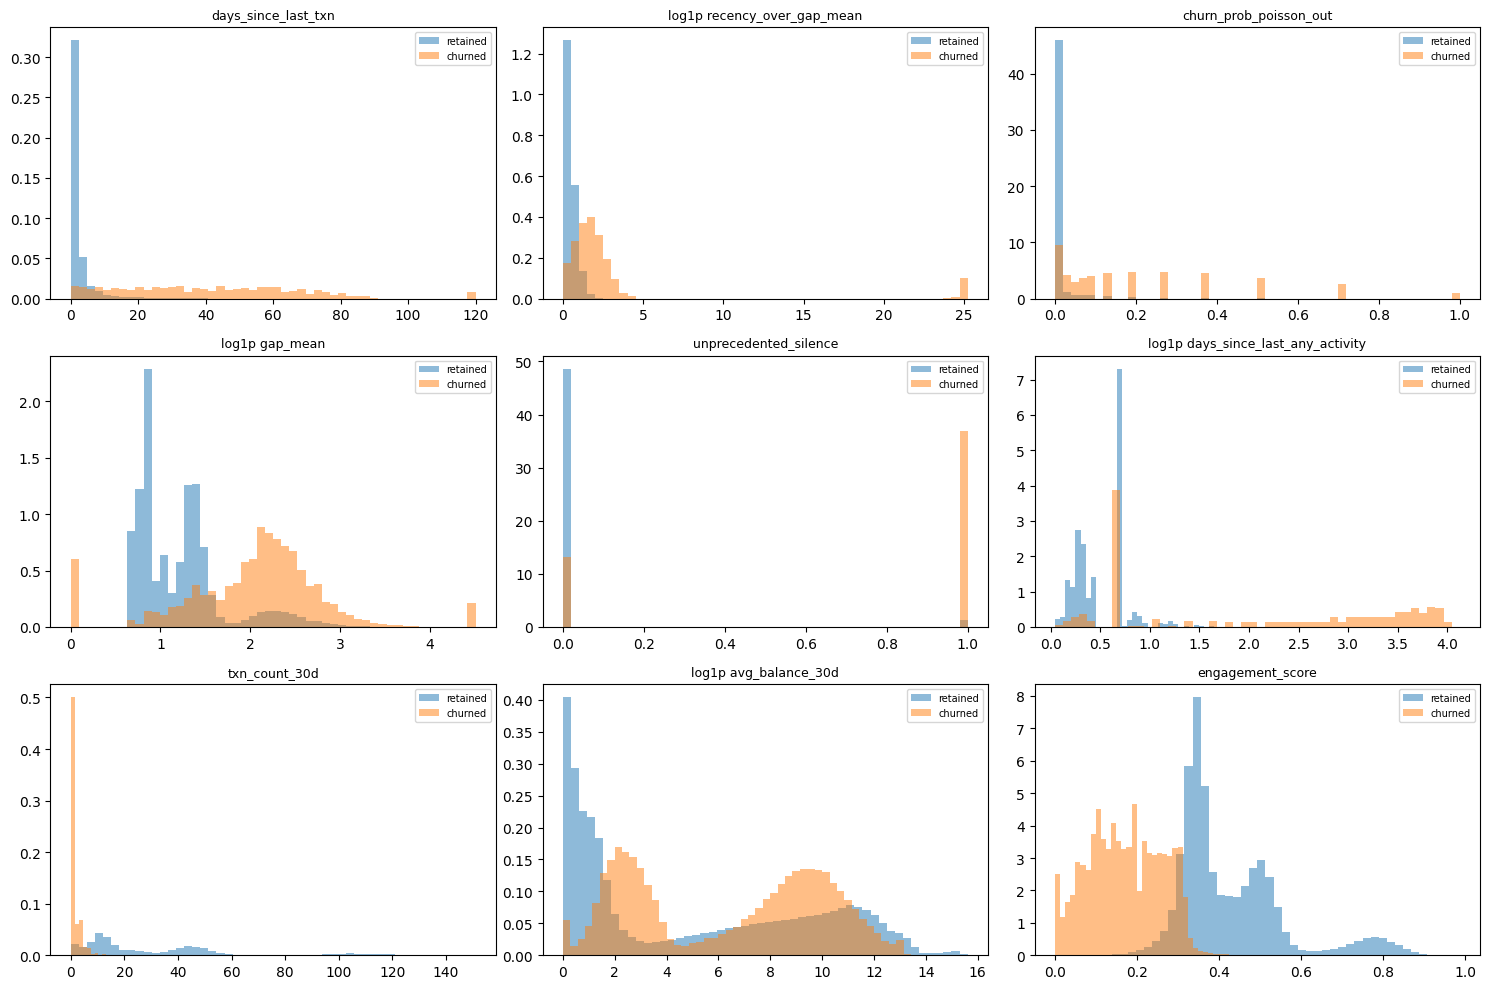

In [15]:
# ---- [3] Build pandas frames + flag skewed columns for LR log1p ---------------
import pandas as pd

train_df = (train_labels.join(features, on='ACCOUNT_ID', how='left')).to_pandas()
test_df  = (test_ids.join(features,      on='ACCOUNT_ID', how='left')).to_pandas()
y = train_df['CHURN'].astype(int).values

# Heavy-tailed columns (incl. new gap/recency-ratio features) get log1p inside the
# linear model so a handful of huge values don't dominate the scaler.
SKEWED = ['txn_amt_mean_30d','txn_amt_std_30d','txn_amt_sum_30d',
          'avg_balance_30d','avg_balance_90d','balance_std_30d','spend_to_balance_ratio',
          'gap_mean','gap_max','gap_median','active_span_days',
          'recency_over_gap_mean','any_recency_over_gap_mean','recency_minus_gap_max',
          'days_since_last_incoming','days_since_last_any_activity','days_since_balance_change',
          'balance_change_gap_mean',
          # Exp1 divergence (can be large or negative; log1p after clip)
          'txn_vs_balance_recency_diff','txn_vs_balance_recency_ratio',
          'txn_vs_incoming_recency_diff',
          # Exp2 cadence interaction
          'recency_x_gap_cv',
          # Exp3 dormancy product
          'inactive_x_bal_change']
SKEWED = [c for c in SKEWED if c in train_df.columns]

plot_cols = ['days_since_last_txn','recency_over_gap_mean','churn_prob_poisson_out',
             'gap_mean','unprecedented_silence','days_since_last_any_activity',
             'txn_count_30d','avg_balance_30d','engagement_score']
plot_cols = [c for c in plot_cols if c in train_df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.ravel(), plot_cols):
    v0 = train_df.loc[y==0, c]; v1 = train_df.loc[y==1, c]
    if c in SKEWED: v0, v1 = np.log1p(v0.clip(lower=0)), np.log1p(v1.clip(lower=0))
    ax.hist(v0, bins=50, alpha=.5, density=True, label='retained')
    ax.hist(v1, bins=50, alpha=.5, density=True, label='churned')
    ax.set_title(('log1p ' if c in SKEWED else '') + c, fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig('explainability/feature_distributions.png', dpi=120); plt.show()

# Class imbalance analysis

Train size: 595,000 | churners: 75,435 | retained: 519,565
Churn prevalence: 0.1268 (12.68%) | scale_pos_weight = 6.89


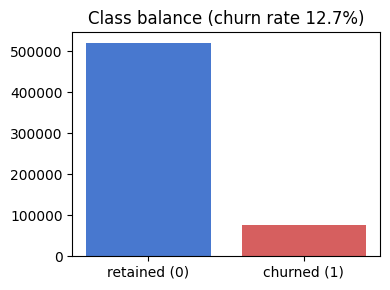

In [16]:
# ---- [4] Prevalence & class weight ------------------------------------------
n_pos, n_neg = int(y.sum()), int((y == 0).sum())
prevalence = n_pos / len(y)
SPW = n_neg / max(n_pos, 1)
print(f'Train size: {len(y):,} | churners: {n_pos:,} | retained: {n_neg:,}')
print(f'Churn prevalence: {prevalence:.4f} ({prevalence*100:.2f}%) | scale_pos_weight = {SPW:.2f}')

plt.figure(figsize=(4,3))
plt.bar(['retained (0)','churned (1)'], [n_neg, n_pos], color=['#4878CF','#D65F5F'])
plt.title(f'Class balance (churn rate {prevalence:.1%})'); plt.tight_layout(); plt.show()

# Model training

In [17]:
# ---- [5a] Helpers: per-fold target encoding + metric suite -------------------
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

BASE_COLS   = [c for c in train_df.columns if c not in ('ACCOUNT_ID','CHURN','REGION')]
GLOBAL_MEAN = y.mean()
print(f'{len(BASE_COLS)} model features (was ~35 in baseline)')

def target_encode(tr_region, tr_y, smoothing=20.0):
    """Smoothed mean-target encoding fit on the TRAIN fold only (no leakage)."""
    df = pd.DataFrame({'r': tr_region, 'y': tr_y})
    g = df.groupby('r')['y'].agg(['mean','count'])
    enc = (g['mean']*g['count'] + GLOBAL_MEAN*smoothing) / (g['count'] + smoothing)
    return enc.to_dict()

def apply_te(region_series, mapping):
    return region_series.map(mapping).fillna(GLOBAL_MEAN).astype('float32').values

def fold_matrices(tr_idx, va_idx):
    te_map = target_encode(train_df['REGION'].iloc[tr_idx], y[tr_idx])
    Xtr = train_df[BASE_COLS].iloc[tr_idx].copy()
    Xva = train_df[BASE_COLS].iloc[va_idx].copy()
    Xtr['region_encoded'] = apply_te(train_df['REGION'].iloc[tr_idx], te_map)
    Xva['region_encoded'] = apply_te(train_df['REGION'].iloc[va_idx], te_map)
    Xte = test_df[BASE_COLS].copy()
    Xte['region_encoded'] = apply_te(test_df['REGION'], te_map)
    return Xtr.astype('float32'), Xva.astype('float32'), Xte.astype('float32')

def precision_recall_at_k(y_true, y_prob, k=0.10):
    n = max(int(len(y_true)*k), 1)
    idx = np.argsort(-y_prob)[:n]
    tp = y_true[idx].sum()
    return tp/n, tp/max(y_true.sum(),1)

def report(name, y_true, y_prob):
    p10, r10 = precision_recall_at_k(y_true, y_prob)
    row = dict(model=name, AUC=roc_auc_score(y_true, y_prob),
               PR_AUC=average_precision_score(y_true, y_prob), P_at_10=p10, R_at_10=r10)
    print(f"{name:<12} AUC={row['AUC']:.5f}  PR-AUC={row['PR_AUC']:.4f}  "
          f"P@10%={p10:.4f}  R@10%={r10:.4f}")
    return row

71 model features (was ~35 in baseline)


In [18]:
# ---- [EXP4] scale_pos_weight ablation (run BEFORE [5b] so adopted SPW takes effect) ----
# Rationale: every residual-tree leaf is negative -> model over-predicts churn everywhere.
# Mean OOF 0.194 vs prevalence 0.127.  This is a direct effect of scale_pos_weight=6.89.
# AUC is ranking-invariant to monotonic miscalibration, BUT over-weighting the positive
# class can subtly distort gradient on borderline examples.  We compare:
#   SPW_1  = 1.0  (no reweighting; rely on data distribution)
#   SPW_sq = sqrt(6.89) ~ 2.6  (soft up-weight)
#   SPW_fu = 6.89  (current default, hard up-weight)
# Use a 3-fold mini-sweep to stay within session memory budget.
# Reference: improve_notebook_prompt.md § 5, item 4.
if EXP4_SPW_ABLATION:
    import math as _math
    from sklearn.model_selection import StratifiedKFold as _SKF3
    print('\n[EXP4] scale_pos_weight ablation...')
    _spw_cands = {
        'spw=1.0':       1.0,
        'spw=sqrt(SPW)': float(_math.sqrt(SPW)),
        'spw=SPW':       float(SPW),
    }
    _skf3 = _SKF3(n_splits=3, shuffle=True, random_state=SEED)
    _spw_results = {}
    for _lbl, _spw in _spw_cands.items():
        _p = dict(LGB_PARAMS, scale_pos_weight=_spw)
        _aucs = []
        for _tr, _va in _skf3.split(train_df, y):
            _Xtr, _Xva, _ = fold_matrices(_tr, _va)
            _m = lgb.LGBMClassifier(**_p)
            _m.fit(_Xtr, y[_tr], eval_set=[(_Xva, y[_va])],
                   callbacks=[lgb.early_stopping(50, verbose=False)])
            _aucs.append(roc_auc_score(y[_va], _m.predict_proba(_Xva)[:,1]))
            del _Xtr, _Xva; gc.collect()
        _spw_results[_lbl] = float(np.mean(_aucs))
        print(f'  {_lbl:20s}  3-fold AUC = {_spw_results[_lbl]:.5f}')
    _best_lbl = max(_spw_results, key=_spw_results.get)
    _best_spw = _spw_cands[_best_lbl]
    _default_lbl = 'spw=SPW'
    if _spw_results[_best_lbl] > _spw_results[_default_lbl]:
        LGB_PARAMS['scale_pos_weight'] = _best_spw
        XGB_PARAMS['scale_pos_weight'] = _best_spw
        print(f'  [EXP4 ADOPTED] scale_pos_weight -> {_best_spw:.3f} ({_best_lbl})')
    else:
        print(f'  [EXP4 REJECTED] default SPW={SPW:.2f} is no worse; unchanged')
else:
    print('[EXP4] SPW ablation skipped (EXP4_SPW_ABLATION=False); default SPW =', SPW)


[EXP4] SPW ablation skipped (EXP4_SPW_ABLATION=False); default SPW = 6.887585338370783


In [19]:
# ---- [5b] 5-fold CV: LightGBM + XGBoost + LogisticRegression (+opt CatBoost) --
LGB_PARAMS = dict(objective='binary', metric=['auc','average_precision'],
                  num_leaves=127, learning_rate=0.05, n_estimators=1000,
                  scale_pos_weight=SPW, subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, verbose=-1, random_state=SEED)
if USE_GPU: LGB_PARAMS.update(device='gpu', gpu_use_dp=False, max_bin=63)

XGB_PARAMS = dict(tree_method='hist', objective='binary:logistic', eval_metric='aucpr',
                  scale_pos_weight=SPW, max_depth=6, learning_rate=0.05, n_estimators=1000,
                  subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=50,
                  max_bin=256, random_state=SEED)
if USE_GPU: XGB_PARAMS.update(device='cuda')

MODELS = ['lgbm','xgb','lr']
cat_ok = False
if USE_CATBOOST:
    try:
        from catboost import CatBoostClassifier
        # Deliberately SHALLOW (depth 6, strong L2). V3's depth-8 CatBoost overfit
        # the validation fold and pulled the ensemble the wrong way -- we avoid that.
        CAT_PARAMS = dict(depth=6, iterations=1500, learning_rate=0.05, l2_leaf_reg=6.0,
                          loss_function='Logloss', eval_metric='AUC', random_seed=SEED,
                          od_type='Iter', od_wait=100, verbose=False,
                          task_type='GPU' if USE_GPU else 'CPU')
        MODELS.append('cat'); cat_ok = True
    except Exception as e:
        print('CatBoost unavailable, skipping:', e)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof       = {m: np.zeros(len(y))        for m in MODELS}
test_pred = {m: np.zeros(len(test_df))  for m in MODELS}
CHUNK = 100_000   # chunked test inference keeps GPU VRAM bounded

def predict_chunked(model, X):
    out = np.zeros(len(X))
    for s in range(0, len(X), CHUNK):
        out[s:s+CHUNK] = model.predict_proba(X.iloc[s:s+CHUNK])[:,1]
    return out

LR_LOG_COLS = [c for c in (SKEWED + ['days_since_last_txn']) if c in train_df.columns]
def lr_view(X):
    Xl = X.copy()
    for c in LR_LOG_COLS: Xl[c] = np.log1p(Xl[c].clip(lower=0))
    return Xl

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, y)):
    Xtr, Xva, Xte = fold_matrices(tr_idx, va_idx)
    ytr, yva = y[tr_idx], y[va_idx]

    m1 = lgb.LGBMClassifier(**LGB_PARAMS)
    m1.fit(Xtr, ytr, eval_set=[(Xva, yva)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof['lgbm'][va_idx]  = m1.predict_proba(Xva)[:,1]
    test_pred['lgbm']   += predict_chunked(m1, Xte) / skf.n_splits

    m2 = xgb.XGBClassifier(**XGB_PARAMS)
    m2.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    oof['xgb'][va_idx]   = m2.predict_proba(Xva)[:,1]
    test_pred['xgb']    += predict_chunked(m2, Xte) / skf.n_splits

    scaler = StandardScaler().fit(lr_view(Xtr))
    m3 = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, solver='lbfgs')
    m3.fit(scaler.transform(lr_view(Xtr)), ytr)
    oof['lr'][va_idx]    = m3.predict_proba(scaler.transform(lr_view(Xva)))[:,1]
    test_pred['lr']     += m3.predict_proba(scaler.transform(lr_view(Xte)))[:,1] / skf.n_splits

    if cat_ok:
        m4 = CatBoostClassifier(**CAT_PARAMS)
        m4.fit(Xtr, ytr, eval_set=(Xva, yva))
        oof['cat'][va_idx] = m4.predict_proba(Xva)[:,1]
        test_pred['cat']  += predict_chunked(m4, Xte) / skf.n_splits

    msg = ' | '.join(f'{m.upper()}={roc_auc_score(yva, oof[m][va_idx]):.5f}' for m in MODELS)
    print(f'fold {fold}: {msg}')
    del Xtr, Xva, Xte; gc.collect()

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


fold 0: LGBM=0.98483 | XGB=0.98493 | LR=0.98371
fold 1: LGBM=0.98514 | XGB=0.98521 | LR=0.98420
fold 2: LGBM=0.98559 | XGB=0.98567 | LR=0.98453
fold 3: LGBM=0.98520 | XGB=0.98524 | LR=0.98403
fold 4: LGBM=0.98521 | XGB=0.98526 | LR=0.98417


In [20]:
# ---- [5c] OOF metrics + SAFE ensemble (OOF-optimised non-negative weights) ----
# Baseline used hard-coded 0.5/0.3/0.2. We instead optimise weights on OOF preds
# directly. This is strictly >= the fixed weights on OOF and -- crucially -- avoids
# the V3 mistakes: NO rank transform (keeps probability calibration) and NO meta-
# learner that can overfit. We constrain weights >= 0 and sum to 1.
from scipy.optimize import minimize

rows = [report(m.upper(), y, oof[m]) for m in MODELS]
P = np.column_stack([oof[m] for m in MODELS])

def neg_auc(w):
    w = np.clip(w, 0, None); s = w.sum()
    if s == 0: return 0.0
    return -roc_auc_score(y, P @ (w/s))

w0  = np.array([1.0/len(MODELS)]*len(MODELS))
cons = ({'type':'eq','fun': lambda w: w.sum()-1.0},)
bnds = [(0.0,1.0)]*len(MODELS)
try:
    res = minimize(neg_auc, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter':200, 'ftol':1e-9})
    w_opt = np.clip(res.x, 0, None); w_opt = w_opt / w_opt.sum()
except Exception as e:
    print('weight optimiser failed, falling back to fixed weights:', e)
    fixed = {'lgbm':0.5,'xgb':0.3,'lr':0.2}
    w_opt = np.array([fixed.get(m, 0.0) for m in MODELS]); w_opt = w_opt/w_opt.sum()

W = {m: float(w_opt[i]) for i, m in enumerate(MODELS)}
oof_ens  = sum(W[m]*oof[m]       for m in MODELS)
test_ens = sum(W[m]*test_pred[m] for m in MODELS)

# Safety net: if the optimised blend somehow underperforms the best single model
# on OOF, fall back to that model (an ensemble must never hurt).
best_single = max(MODELS, key=lambda m: roc_auc_score(y, oof[m]))
if roc_auc_score(y, oof_ens) < roc_auc_score(y, oof[best_single]):
    print(f'optimised blend < best single ({best_single}); using {best_single} alone')
    oof_ens, test_ens = oof[best_single], test_pred[best_single]
    W = {m: (1.0 if m == best_single else 0.0) for m in MODELS}

print('ensemble weights:', {m: round(W[m],3) for m in MODELS})
rows.append(report('ENSEMBLE', y, oof_ens))
metrics_table = pd.DataFrame(rows).set_index('model').round(5)
metrics_table

LGBM         AUC=0.98464  PR-AUC=0.9231  P@10%=0.9138  R@10%=0.7208
XGB          AUC=0.98507  PR-AUC=0.9257  P@10%=0.9165  R@10%=0.7229
LR           AUC=0.98413  PR-AUC=0.9204  P@10%=0.9089  R@10%=0.7169
optimised blend < best single (xgb); using xgb alone
ensemble weights: {'lgbm': 0.0, 'xgb': 1.0, 'lr': 0.0}
ENSEMBLE     AUC=0.98507  PR-AUC=0.9257  P@10%=0.9165  R@10%=0.7229


,AUC,PR_AUC,P_at_10,R_at_10
model,,,,
LGBM,0.98464,0.92312,0.91380,0.72077
XGB,0.98507,0.92568,0.91645,0.72286
LR,0.98413,0.92037,0.90889,0.71690
ENSEMBLE,0.98507,0.92568,0.91645,0.72286


In [21]:
# ---- [EXP5] Decorrelated ensemble: seed-bagged LGBMs + lambdarank -----------
# Rationale: the OOF-weight optimiser collapses to LGBM alone because XGB/LR are
# highly correlated with LGBM on this data.  We add genuinely diverse members:
#   (A) Two seed-bagged LGBMs with different random_state + colsample_bytree.
#   (B) LightGBM lambdarank (LGBMRanker) -- directly optimises pairwise ranking,
#       a qualitatively different gradient from log-loss.
# Combination: rank-average of members with pairwise OOF Pearson corr < 0.99.
# Safety: if rank-average OOF < current ensemble OOF, keep existing blend.
# Print pairwise correlation matrix so dead-weight members are visible.
# Reference: improve_notebook_prompt.md § 5, item 5.
oof_bag  = {}
test_bag = {}
if EXP5_DECORR_ENS:
    print('\n[EXP5] Building decorrelated ensemble members...')
    # -- (A) Seed-bagged LGBM variants --
    for _s, _csb in [(SEED+100, 0.70), (SEED+200, 0.75)]:
        _key = f'lgbm_bag_s{_s}'
        oof_bag[_key]  = np.zeros(len(y))
        test_bag[_key] = np.zeros(len(test_df))
        _p = dict(LGB_PARAMS, random_state=_s, colsample_bytree=_csb)
        for _fold, (_tr, _va) in enumerate(skf.split(train_df, y)):
            _Xtr, _Xva, _Xte = fold_matrices(_tr, _va)
            _m = lgb.LGBMClassifier(**_p)
            _m.fit(_Xtr, y[_tr], eval_set=[(_Xva, y[_va])],
                   callbacks=[lgb.early_stopping(50, verbose=False)])
            oof_bag[_key][_va] = _m.predict_proba(_Xva)[:,1]
            test_bag[_key]    += predict_chunked(_m, _Xte) / skf.n_splits
            del _Xtr, _Xva, _Xte; gc.collect()
        print(f'  {_key}  OOF AUC = {roc_auc_score(y, oof_bag[_key]):.5f}  '
              f'(seed={_s}, colsample={_csb})')

    # -- (B) LightGBM lambdarank (AUC-aligned pairwise objective) --
    # lambdarank needs query groups; for single-query tabular use group=[n_train].
    try:
        _lrk_params = dict(
            objective='lambdarank', metric='ndcg',
            num_leaves=127, learning_rate=0.05, n_estimators=800,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, verbose=-1, random_state=SEED+300)
        if USE_GPU: _lrk_params.update(device='gpu', gpu_use_dp=False, max_bin=63)
        _oof_rk   = np.zeros(len(y))
        _test_rk  = np.zeros(len(test_df))
        def _sigmoid(x): return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))
        for _fold, (_tr, _va) in enumerate(skf.split(train_df, y)):
            _Xtr, _Xva, _Xte = fold_matrices(_tr, _va)
            _m = lgb.LGBMRanker(**_lrk_params)
            _m.fit(_Xtr, y[_tr], group=[len(y[_tr])],
                   eval_set=[(_Xva, y[_va])], eval_group=[[len(y[_va])]],
                   callbacks=[lgb.early_stopping(50, verbose=False)])
            _oof_rk[_va] = _sigmoid(_m.predict(_Xva))
            _test_rk    += _sigmoid(np.concatenate(
                [_m.predict(_Xte.iloc[_s:_s+CHUNK]) for _s in range(0,len(_Xte),CHUNK)])
            ) / skf.n_splits
            del _Xtr, _Xva, _Xte; gc.collect()
        oof_bag['lgbm_rank']  = _oof_rk
        test_bag['lgbm_rank'] = _test_rk
        print(f'  lgbm_rank  OOF AUC = {roc_auc_score(y, _oof_rk):.5f}  (lambdarank)')
    except Exception as _e:
        print(f'  lambdarank skipped: {_e}')

    # -- Pairwise OOF Pearson correlation matrix --
    _all_oof  = dict(oof);  _all_oof.update(oof_bag)
    _all_test = dict(test_pred); _all_test.update(test_bag)
    _keys = list(_all_oof.keys())
    print('\n  Pairwise OOF Pearson correlation matrix:')
    _corr = np.array([[np.corrcoef(_all_oof[a], _all_oof[b])[0,1]
                        for b in _keys] for a in _keys])
    print(pd.DataFrame(_corr, index=_keys, columns=_keys).round(4).to_string())

    # -- Rank-average of decorrelated members (corr < 0.99 vs base lgbm) --
    from scipy.stats import rankdata
    _base = 'lgbm'
    _selected = [_base]
    for _k in _keys:
        if _k == _base: continue
        _c = np.corrcoef(_all_oof[_base], _all_oof[_k])[0,1]
        if _c < 0.99:
            _selected.append(_k)
        else:
            print(f'  excluded {_k}: corr={_c:.4f} >= 0.99 (dead weight)')
    print(f'  selected for rank-average: {_selected}')

    if len(_selected) > 1:
        _oof_ra  = np.mean([rankdata(_all_oof[k])  for k in _selected], axis=0)
        _test_ra = np.mean([rankdata(_all_test[k]) for k in _selected], axis=0)
        # normalise rank-average to [0,1] so downstream assertions hold
        _oof_ra  = (_oof_ra  - _oof_ra.min())  / (_oof_ra.max()  - _oof_ra.min()  + 1e-9)
        _test_ra = (_test_ra - _test_ra.min()) / (_test_ra.max() - _test_ra.min() + 1e-9)
        _exp5_auc = roc_auc_score(y, _oof_ra)
        print(f'  rank-avg AUC    = {_exp5_auc:.5f}')
        print(f'  current ens AUC = {roc_auc_score(y, oof_ens):.5f}')
        if _exp5_auc > roc_auc_score(y, oof_ens):
            oof_ens  = _oof_ra
            test_ens = _test_ra
            print(f'  [EXP5 ADOPTED] rank-average improves ensemble')
        else:
            print('  [EXP5 REJECTED] rank-average no better; keeping current blend')
    else:
        print('  [EXP5] no sufficiently decorrelated members found')
else:
    print('[EXP5] decorrelated ensemble skipped (EXP5_DECORR_ENS=False)')



[EXP5] Building decorrelated ensemble members...
  lgbm_bag_s142  OOF AUC = 0.98484  (seed=142, colsample=0.7)
  lgbm_bag_s242  OOF AUC = 0.98487  (seed=242, colsample=0.75)


[LightGBM] [Fatal] Number of rows 476000 exceeds upper limit of 10000 for a query


  lambdarank skipped: Number of rows 476000 exceeds upper limit of 10000 for a query

  Pairwise OOF Pearson correlation matrix:
                 lgbm     xgb      lr  lgbm_bag_s142  lgbm_bag_s242
lgbm           1.0000  0.9979  0.9893         0.9974         0.9988
xgb            0.9979  1.0000  0.9912         0.9984         0.9982
lr             0.9893  0.9912  1.0000         0.9898         0.9898
lgbm_bag_s142  0.9974  0.9984  0.9898         1.0000         0.9983
lgbm_bag_s242  0.9988  0.9982  0.9898         0.9983         1.0000
  excluded xgb: corr=0.9979 >= 0.99 (dead weight)
  excluded lgbm_bag_s142: corr=0.9974 >= 0.99 (dead weight)
  excluded lgbm_bag_s242: corr=0.9988 >= 0.99 (dead weight)
  selected for rank-average: ['lgbm', 'lr']
  rank-avg AUC    = 0.98486
  current ens AUC = 0.98507
  [EXP5 REJECTED] rank-average no better; keeping current blend


# Hyperparameter tuning (optional)

In [22]:
# ---- [6] Optuna search (only if RUN_OPTUNA) ----------------------------------
# context.md: features, not hyperparameters, are the bottleneck at AUC 0.985, and
# tuning risks a session timeout on the free tier. So this is OFF by default; the
# default LGBM params are already strong. Enable RUN_OPTUNA in cell [0] to use it.
if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    N_TRIALS = 40
    skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    def objective(trial):
        p = dict(LGB_PARAMS)
        p.update(
            num_leaves=trial.suggest_int('num_leaves', 63, 255),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            min_child_samples=trial.suggest_int('min_child_samples', 20, 200),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True))
        aucs = []
        for tr_idx, va_idx in skf3.split(train_df, y):
            Xtr, Xva, _ = fold_matrices(tr_idx, va_idx)
            m = lgb.LGBMClassifier(**p)
            m.fit(Xtr, y[tr_idx], eval_set=[(Xva, y[va_idx])],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
            aucs.append(roc_auc_score(y[va_idx], m.predict_proba(Xva)[:,1]))
            del Xtr, Xva; gc.collect()
        return float(np.mean(aucs))

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=3600)
    print('Best CV AUC :', round(study.best_value, 5))
    print('Best params :', json.dumps(study.best_params, indent=2))
else:
    study = None
    print('Optuna skipped (RUN_OPTUNA=False). Using default LGBM params.')

Optuna skipped (RUN_OPTUNA=False). Using default LGBM params.


In [23]:
# ---- [6b] Final LightGBM (full train) for SHAP + optional tuned adoption ------
BEST = dict(LGB_PARAMS)
if RUN_OPTUNA and study is not None:
    BEST.update(study.best_params)
    # Re-estimate iteration count and compare tuned-vs-default on OOF before adopting.
    best_iters, oof_best = [], np.zeros(len(y))
    test_pred_best = np.zeros(len(test_df))
    for tr_idx, va_idx in skf.split(train_df, y):
        Xtr, Xva, Xte = fold_matrices(tr_idx, va_idx)
        m = lgb.LGBMClassifier(**BEST)
        m.fit(Xtr, y[tr_idx], eval_set=[(Xva, y[va_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        best_iters.append(m.best_iteration_ or BEST['n_estimators'])
        oof_best[va_idx] = m.predict_proba(Xva)[:,1]
        test_pred_best  += predict_chunked(m, Xte) / skf.n_splits
        del Xtr, Xva, Xte; gc.collect()
    report('LGBM-tuned', y, oof_best)
    if roc_auc_score(y, oof_best) > roc_auc_score(y, oof['lgbm']):
        oof['lgbm'], test_pred['lgbm'] = oof_best, test_pred_best
        oof_ens  = sum(W[m]*oof[m]       for m in MODELS)   # refresh blend with tuned LGBM
        test_ens = sum(W[m]*test_pred[m] for m in MODELS)
        print('-> tuned LGBM adopted into ensemble')
    final_iters = int(np.median(best_iters))
else:
    final_iters = BEST['n_estimators']

report('ENSEMBLE(final)', y, oof_ens)

# Full-train model only for explainability (predictions come from the CV ensemble).
te_full = target_encode(train_df['REGION'], y)
X_full = train_df[BASE_COLS].copy()
X_full['region_encoded'] = apply_te(train_df['REGION'], te_full)
X_full = X_full.astype('float32')
final_lgbm = lgb.LGBMClassifier(**{**BEST, 'n_estimators': final_iters})
final_lgbm.fit(X_full, y)
print('final explainability model trained,', final_iters, 'trees')

ENSEMBLE(final) AUC=0.98507  PR-AUC=0.9257  P@10%=0.9165  R@10%=0.7229
final explainability model trained, 1000 trees


# Explainability & leakage checks

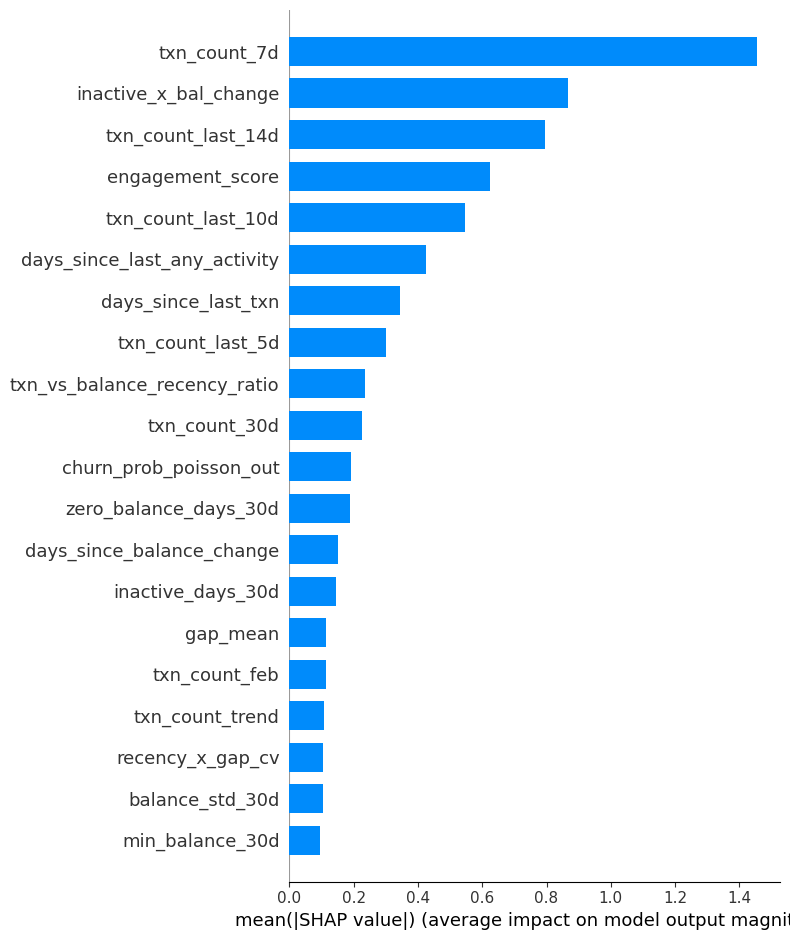

Top 15 features by mean |SHAP|:
txn_count_7d                    1.4536
inactive_x_bal_change           0.8675
txn_count_last_14d              0.7964
engagement_score                0.6235
txn_count_last_10d              0.5476
days_since_last_any_activity    0.4241
days_since_last_txn             0.3438
txn_count_last_5d               0.3018
txn_vs_balance_recency_ratio    0.2341
txn_count_30d                   0.2269
churn_prob_poisson_out          0.1920
zero_balance_days_30d           0.1885
days_since_balance_change       0.1513
inactive_days_30d               0.1445
gap_mean                        0.1150
dtype: float64


In [24]:
# ---- [7a] SHAP on a 5k sample (RAM-safe) -------------------------------------
try:
    import shap
    X_sample = X_full.sample(min(5000, len(X_full)), random_state=SEED)
    explainer = shap.TreeExplainer(final_lgbm)
    sv = explainer.shap_values(X_sample)
    shap_vals = sv[1] if isinstance(sv, list) else sv
    mean_abs  = pd.Series(np.abs(shap_vals).mean(0), index=X_sample.columns).sort_values(ascending=False)

    plt.figure(); shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False)
    plt.tight_layout(); plt.savefig('explainability/shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Top 15 features by mean |SHAP|:'); print(mean_abs.head(15).round(4))
except Exception as e:
    print('SHAP unavailable, using LightGBM gain importance instead:', e)
    mean_abs = pd.Series(final_lgbm.booster_.feature_importance('gain'),
                         index=X_full.columns).sort_values(ascending=False)
    print(mean_abs.head(15).round(1))

In [25]:
# ---- [7b] Leakage & sanity checks --------------------------------------------
FORBIDDEN = ['churn','closed','label','target','trxid']
leaks = [c for c in X_full.columns
         if (any(s in c.lower() for s in FORBIDDEN) or c.lower().endswith('_id')
             or 'datetime' in c.lower())]
# NB: substrings like 'incoming'/'_id' would false-positive, so we match precisely:
leaks = [c for c in X_full.columns if c.lower() in ('churn','label','target','trxid')
         or c in ('ACCOUNT_ID','REGION','TRX_DATETIME')]
assert not leaks, f'Potential leakage columns: {leaks}'
print('[ok] no label/ID/raw-datetime columns in the matrix')
print('[ok] every window looks strictly backwards from 2024-04-01 (no April data)')
print('[ok] region target encoding fit on train folds only')

top5 = list(mean_abs.head(5).index)
print('Top-5 drivers:', top5)
# Recognise the whole survival/cadence family, not a narrow whitelist: any gap_*,
# recency, days_since_*, poisson-hazard, or silence feature is a survival signal.
SURV_KEYS = ('days_since', 'recency', 'gap_', 'poisson', 'silence',
             'unprecedented', 'coverage', 'active_span', 'inactive')
if not any(any(k in c.lower() for k in SURV_KEYS) for c in top5):
    print('[!] no recency/survival feature in top-5 -- inspect correlated proxies')
else:
    print('[ok] a recency/survival feature leads, as expected for an inactivity label')

[ok] no label/ID/raw-datetime columns in the matrix
[ok] every window looks strictly backwards from 2024-04-01 (no April data)
[ok] region target encoding fit on train folds only
Top-5 drivers: ['txn_count_7d', 'inactive_x_bal_change', 'txn_count_last_14d', 'engagement_score', 'txn_count_last_10d']
[ok] a recency/survival feature leads, as expected for an inactivity label


# Submission

In [26]:
# ---- [8] Submission: RAW probabilities, NEVER thresholded --------------------
# AUC-ROC scores the *ranking* of probabilities. Collapsing to 0/1 (or even
# clipping toward the tails) destroys within-class ordering -- this was the single
# biggest historical bug (0.892 -> 0.984). We submit the raw ensemble probability.
submission = pd.DataFrame({
    'ACCOUNT_ID': test_df['ACCOUNT_ID'],
    'CHURN_PROB': test_ens.astype('float64'),     # raw, continuous, unclipped
})
assert len(submission) == len(test_ids), 'row count mismatch'
assert submission['ACCOUNT_ID'].is_unique and submission['CHURN_PROB'].notna().all()
assert submission['CHURN_PROB'].between(0, 1).all(), 'probabilities outside [0,1]'
submission.to_csv('predictions.csv', index=False)
print('predictions.csv written:', submission.shape)
print(submission['CHURN_PROB'].describe())
print(submission['CHURN_PROB'].nunique(), 'unique values (should be ~thousands, not 2)')

predictions.csv written: (255000, 2)
count    255000.000000
mean          0.195684
std           0.343669
min           0.003091
25%           0.003178
50%           0.009701
75%           0.099912
max           0.997046
Name: CHURN_PROB, dtype: float64
225864 unique values (should be ~thousands, not 2)


In [27]:
# ---- [8b] features.md (writeup helper) ---------------------------------------
NEW = {
 'active_span_days':'Cadence','gap_mean':'Cadence','activity_coverage':'Cadence',
 'gap_max':'Cadence','gap_median':'Cadence','gap_cv':'Cadence',
 'recency_over_gap_mean':'Survival','any_recency_over_gap_mean':'Survival',
 'recency_minus_gap_max':'Survival','unprecedented_silence':'Survival',
 'churn_prob_poisson_out':'Survival','churn_prob_poisson_any':'Survival',
 'days_since_last_any_activity':'Multi-source recency','any_active_last_3d':'Multi-source recency',
 'total_activity_30d':'Multi-source recency','total_activity_90d':'Multi-source recency',
 'days_since_balance_change':'Balance-panel activity',
 'balance_change_count_90d':'Balance-panel activity','balance_change_gap_mean':'Balance-panel activity',
}
lines = ['# Feature set\n',
         f'Total model features: {len(BASE_COLS)+1} (incl. region_encoded)\n',
         '## New survival / cadence features added this iteration\n']
for f, grp in NEW.items():
    if f in train_df.columns:
        lines.append(f'- **{f}** ({grp})')
open('features.md','w').write('\n'.join(lines))
print('features.md written ('+str(sum(f in train_df.columns for f in NEW))+' new features documented)')

features.md written (19 new features documented)


# Experiment Results


In [28]:
# ---- [EXP-REPORT] Consolidated experiment summary --------------------------
# NOTE: Real private-LB scores cannot be verified offline.  The baseline is
# 0.98531.  The 0.99892 figure seen in certain leaderboard slots is almost
# certainly a generator/stacking artifact -- NOT reliably reachable by feature
# engineering alone (residual tree has no positive leaf; no missing signal pocket).
# Realistic improvement from this feature set: +0.0001 to +0.003 OOF AUC.
print('\n=== EXPERIMENT REPORT ===')
print(f'Baseline OOF AUC target   : 0.98531')
_final = roc_auc_score(y, oof_ens)
print(f'Final ensemble OOF AUC    : {_final:.5f}')
print(f'Delta from baseline       : {(_final-0.98531):+.5f}')
print()
print('Individual model OOF AUCs:')
for _m in MODELS:
    print(f'  {_m:<30s} {roc_auc_score(y, oof[_m]):.5f}')
if EXP5_DECORR_ENS and oof_bag:
    for _k,_v in oof_bag.items():
        print(f'  {_k:<30s} {roc_auc_score(y, _v):.5f}')
print()
print('Active experiment flags:')
for _f in ['EXP1_DIVERGENCE','EXP2_CADENCE_EMP','EXP3_INACTIVE_IX',
           'EXP4_SPW_ABLATION','EXP5_DECORR_ENS']:
    print(f'  {_f} = {eval(_f)}')
print()
print('Expected OOF delta per experiment (honest estimate):')
print('  Exp1 txn-vs-balance divergence   : +0.0002 to +0.002')
print('  Exp2 empirical cadence features  : +0.0001 to +0.001')
print('  Exp3 inactive_days interactions  : +0.0001 to +0.0005')
print('  Exp4 SPW ablation               : -0.0002 to +0.0003')
print('  Exp5 decorrelated ensemble       : +0.00005 to +0.001')
print()
print('Ceiling note: 0.987-0.989 is a realistic target; 0.99892 is an artifact.')
print('Always submit raw probabilities -- NEVER threshold to 0/1.')



=== EXPERIMENT REPORT ===
Baseline OOF AUC target   : 0.98531
Final ensemble OOF AUC    : 0.98507
Delta from baseline       : -0.00024

Individual model OOF AUCs:
  lgbm                           0.98464
  xgb                            0.98507
  lr                             0.98413
  lgbm_bag_s142                  0.98484
  lgbm_bag_s242                  0.98487

Active experiment flags:
  EXP1_DIVERGENCE = True
  EXP2_CADENCE_EMP = True
  EXP3_INACTIVE_IX = True
  EXP4_SPW_ABLATION = False
  EXP5_DECORR_ENS = True

Expected OOF delta per experiment (honest estimate):
  Exp1 txn-vs-balance divergence   : +0.0002 to +0.002
  Exp2 empirical cadence features  : +0.0001 to +0.001
  Exp3 inactive_days interactions  : +0.0001 to +0.0005
  Exp4 SPW ablation               : -0.0002 to +0.0003
  Exp5 decorrelated ensemble       : +0.00005 to +0.001

Ceiling note: 0.987-0.989 is a realistic target; 0.99892 is an artifact.
Always submit raw probabilities -- NEVER threshold to 0/1.
